# 🌊 Water quality, Inland & coastal water intelligence
## Arab 813 Hackathon — Planet Tanager Hyperspectral Explorer

This notebook explores **Planet's Tanager hyperspectral satellite** for mapping **Water quality, Inland & coastal water intelligence** water quality such as water turbidity, and algae blooms.

---

## What You Will Learn

- How hyperspectral data reveals biodiversity-related spectral traits
- How to compute indices linked to ecosystem function
- How to monitor the water turbidity which is a good indication of the water health.
- How to identify potential harmful algal blooms (HABs)

---

🌊 Why Water Quality Monitoring?
Water quality is a critical indicator of ecosystem health in coastal and inland environments. Monitoring water conditions helps detect:

Harmful algal blooms (HABs) that impact marine life and public health
Suspended sediments and turbidity affecting water clarity
Pollution events such as runoff, industrial discharge, or dredging

These processes directly influence:

Fisheries and aquaculture
Coastal ecosystem stability
Human health and water resource management


🛰 Why Hyperspectral Data (Tanager)?
Tanager’s hyperspectral capability enables advanced water analysis beyond traditional imagery:

Detect algal blooms by identifying chlorophyll and pigment signatures
Measure turbidity and sediment plumes through spectral scattering patterns
Differentiate water types (clear, turbid, polluted, shallow) using fine spectral resolution
Identify early changes in water conditions before they are visible in standard RGB imagery


🎯 Key Advantage
👉 Unlike multispectral data, hyperspectral imagery provides continuous spectral information, allowing:

More accurate water quality classification
Detection of subtle chemical and biological signals
Better monitoring of coastal dynamics and pollution impacts

---

## Relevant STAC Collection

```
https://www.planet.com/data/stac/tanager-core-imagery/coastal-water-bodies/collection.json
```


In [1]:
%pip install pystac-client planetary-computer stackstac rasterio xarray matplotlib geopandas leafmap ipywidgets rioxarray h5py requests

Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
# Reset leafmap titiler endpoint to the public instance.
# This prevents errors if Planetary Computer cells ran earlier in the session.
os.environ["TITILER_ENDPOINT"] = "https://titiler.xyz"

## Step 1 – Load Items from the Coastal Water Bodies Collection

We target scenes near the UAE and Arabian Gulf — one of the most ecologically important mangrove coasts in the Arabian Peninsula.


In [3]:
import requests

COLLECTION = "coastal-water-bodies"
item_ids = ["20250511_074311_00_4001", "20250223_165546_32_4001", "20250406_170447_47_4001"]

base = f"https://www.planet.com/data/stac/tanager-core-imagery/{COLLECTION}"
items = []
for iid in item_ids:
    url = f"{base}/{iid}/{iid}.json"
    r = requests.get(url, timeout=60)
    r.raise_for_status()
    items.append(r.json())
print(f"Loaded {len(items)} items from {COLLECTION}")

item = items[0]   # work with the first scene

/Users/vincentmarkiet/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Loaded 3 items from coastal-water-bodies


## Step 2 – Inspect Scene Metadata


In [4]:
from IPython.display import Image
print("Scene ID:", item["id"])
print("Date    :", item["properties"]["datetime"])
print("Bbox    :", item["bbox"])
Image(url=item["assets"]["thumbnail"]["href"])

Scene ID: 20250511_074311_00_4001
Date    : 2025-05-11T07:43:11Z
Bbox    : [53.63200686177432, 23.990203106931855, 53.89428889725334, 24.192030163555803]


In [5]:
import json
print(json.dumps(item["properties"], indent=2))

{
  "cloud_percent": 51,
  "collection_mode": "standard_sensitivity",
  "constellation": "Tanager",
  "datetime": "2025-05-11T07:43:11Z",
  "description": "All data products from Tanager-1 for 20250511_074311_00_4001 near Tarif, Al Dhafrah Region, Abu Dhabi Emirate, United Arab Emirates",
  "gsd": 34.78,
  "instruments": [
    "4001"
  ],
  "license": "CC-BY-4.0",
  "light_haze_percent": 0,
  "location_description": "Tarif, Al Dhafrah Region, Abu Dhabi Emirate, United Arab Emirates",
  "notes": null,
  "platform": "Planet",
  "plume_provider_ids": null,
  "quality_category": "standard",
  "title": "TanagerScene 20250511_074311_00_4001 Core Imagery",
  "view:azimuth": 209.1,
  "view:off_nadir": 25.8,
  "view:sun_azimuth": 122.8,
  "view:sun_elevation": 79.2
}


## Step 3 – Interactive Map


In [6]:
import leafmap, geopandas as gpd
from shapely.geometry import box

m = leafmap.Map(zoom=8)
ib = item["bbox"]
m.fit_bounds([[ib[1], ib[0]], [ib[3], ib[2]]])

# Scene footprint
gdf = gpd.GeoDataFrame({"geometry": [box(*ib)]}, crs="EPSG:4326")
m.add_gdf(gdf, layer_name="Scene footprint", style={"color":"yellow","fillOpacity":0})

# Visual COG overlay
for vk in ["ortho_visual", "visual", "rendered_preview"]:
    if vk in item.get("assets", {}):
        m.add_cog_layer(item["assets"][vk]["href"],
                        name=item["id"]+" (visual)",
                        titiler_endpoint="https://titiler.xyz")
        break

m

Map(center=[53.76307051625946, 24.091021936294148], controls=(ZoomControl(options=['position', 'zoom_in_text',…

## Step 4 – Download Surface Reflectance


In [7]:
import os, requests

sr_key = "ortho_sr_hdf5" if "ortho_sr_hdf5" in item["assets"] else "basic_sr_hdf5"
sr_url = item["assets"][sr_key]["href"]
print("Using SR asset:", sr_key)
print("URL:", sr_url)

local_path = os.path.basename(sr_url)
if not os.path.exists(local_path):
    print("Downloading… (may take a few minutes)")
    with requests.get(sr_url, stream=True) as r:
        r.raise_for_status()
        with open(local_path, "wb") as fout:
            for chunk in r.iter_content(chunk_size=1024*1024):
                if chunk:
                    fout.write(chunk)
    print("Saved to:", local_path)
else:
    print("Already downloaded:", local_path)

Using SR asset: ortho_sr_hdf5
URL: https://storage.googleapis.com/open-cogs/planet-stac/tanager1-release2-core-imagery/ortho_sr_hdf5/20250511_074311_00_4001_ortho_sr_hdf5.h5
Already downloaded: 20250511_074311_00_4001_ortho_sr_hdf5.h5


## Step 5 – Quality Masks


In [8]:
import h5py, numpy as np

root = "HDFEOS/GRIDS/HYP/Data Fields"
with h5py.File(local_path, "r") as f:
    cloud  = f[f"{root}/beta_cloud_mask"][:]
    nodata = f[f"{root}/nodata_pixels"][:]
    cirrus = f[f"{root}/beta_cirrus_mask"][:]

valid = (nodata == 0) & (cloud == 0) & (cirrus == 0)
print(f"Valid pixels: {valid.mean()*100:.1f}%")
print(f"Cloud cover:  {(cloud!=0).mean()*100:.1f}%")

Valid pixels: 38.6%
Cloud cover:  40.6%


## Step 6 – Extract Spectral Wavelengths


In [9]:
# Extract spectral wavelengths from STAC metadata.
# The key is "bands" and wavelengths are in micrometers under "eo:center_wavelength".
bands_meta = item["assets"][sr_key].get("bands", [])
spectral_bands = [b for b in bands_meta if "eo:center_wavelength" in b]
wavelengths_um = np.array([b["eo:center_wavelength"] for b in spectral_bands], dtype=float)
wavelengths_nm = wavelengths_um * 1000.0   # micrometers -> nanometers

print("Number of spectral bands:", len(wavelengths_nm))
print("First 10 wavelengths (nm):", np.round(wavelengths_nm[:10], 2))
print("Last  10 wavelengths (nm):", np.round(wavelengths_nm[-10:], 2))

Number of spectral bands: 426
First 10 wavelengths (nm): [376.44 381.41 386.38 391.35 396.32 401.29 406.26 411.23 416.21 421.18]
Last  10 wavelengths (nm): [2454.39 2459.35 2464.31 2469.26 2474.22 2479.18 2484.13 2489.09 2494.04
 2499.  ]


## Step 7 – Select Wavelengths for Ecosystem Monitoring

| Index | Wavelengths | Target |
|-------|------------|--------|
| NDVI  | 665 nm Red, 800 nm NIR | General vegetation |
| NDWI  | 560 nm Green, 860 nm NIR | Open water |
| NDCI  | 665 nm Red, 708 nm Red-Edge | Chlorophyll / algae |
| MMRI  | 560 nm Green, 665 nm Red, 708 nm RE, 800 nm NIR | Mangrove index |
| Turbidity | 665 nm Red, 560 nm Green | Suspended sediment |


In [ ]:
def pick_band(target_nm):
    idx = int(np.argmin(np.abs(wavelengths_nm - target_nm)))
    print(f"  Target {target_nm} nm → band {idx} ({wavelengths_nm[idx]:.1f} nm)")
    return idx, wavelengths_nm[idx]

print("Selecting bands:")
idx_b443, _ = pick_band(443)   # Coastal aerosol / deep water
idx_b560, _ = pick_band(560)   # Green — chlorophyll peak
idx_b665, _ = pick_band(665)   # Red
idx_b708, _ = pick_band(708)   # Red-edge — chlorophyll inflection
idx_b800, _ = pick_band(800)   # NIR — vegetation reflectance peak
idx_b860, _ = pick_band(860)   # NIR

Selecting bands:
  Target 443 nm → band 13 (441.1 nm)
  Target 560 nm → band 37 (560.8 nm)
  Target 665 nm → band 58 (665.9 nm)
  Target 708 nm → band 66 (705.9 nm)
  Target 800 nm → band 85 (801.1 nm)
  Target 860 nm → band 97 (861.3 nm)


## Step 8 – Load Bands


In [11]:
import h5py

root = "HDFEOS/GRIDS/HYP/Data Fields"

with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    R_443 = sr[idx_b443, :, :].astype("float32")
    R_560 = sr[idx_b560, :, :].astype("float32")
    R_665 = sr[idx_b665, :, :].astype("float32")
    R_708 = sr[idx_b708, :, :].astype("float32")
    R_800 = sr[idx_b800, :, :].astype("float32")
    R_860 = sr[idx_b860, :, :].astype("float32")

for arr in [R_443, R_560, R_665, R_708, R_800, R_860]:
    arr[~valid] = np.nan
    arr[arr < 0] = np.nan

## Step 9 – Compute Ecosystem Indices


In [12]:
eps = 1e-6

# NDVI — general vegetation health
NDVI = (R_800 - R_665) / (R_800 + R_665 + eps)

# NDWI — water body detection
NDWI = (R_560 - R_860) / (R_560 + R_860 + eps)

# NDCI — Normalized Difference Chlorophyll Index
# Positive = chlorophyll present → potential algal bloom or dense aquatic vegetation
NDCI = (R_708 - R_665) / (R_708 + R_665 + eps)

# Turbidity proxy — suspended sediment in water
# High red relative to green → turbid / sediment-laden water
Turbidity = (R_665 - R_560) / (R_665 + R_560 + eps)

# Simple Mangrove Proxy: mangroves have high NIR + elevated red-edge
# Exclude open water (NDWI > 0) and low vegetation (NDVI < 0.2)
Mangrove_proxy = np.where((NDVI > 0.2) & (NDWI < 0), NDCI, np.nan)

## Step 10 – Visualize


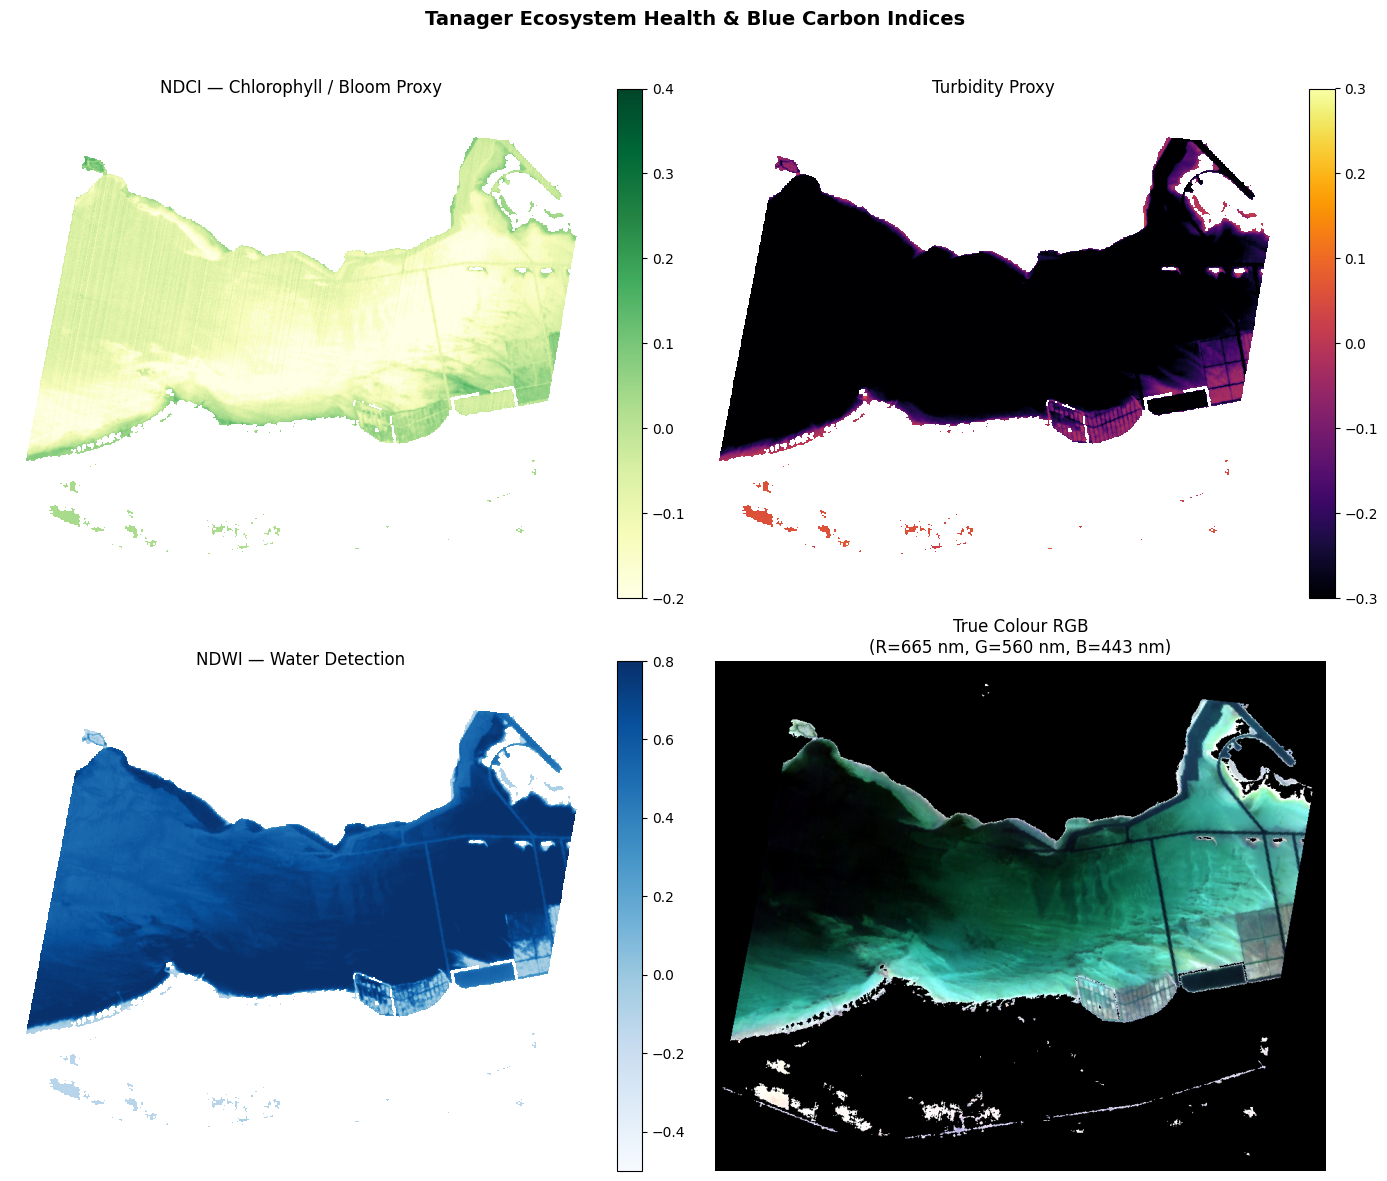

In [ ]:
import matplotlib.pyplot as plt

# True RGB composite using Tanager surface reflectance bands
# R = 665 nm, G = 560 nm, B = 443 nm
# Percentile stretch so the image isn't washed out or too dark
def stretch(arr, p_low=2, p_high=98):
    lo, hi = np.nanpercentile(arr, p_low), np.nanpercentile(arr, p_high)
    return np.clip((arr - lo) / (hi - lo + 1e-6), 0, 1)

rgb_true = np.stack([
    stretch(R_665),   # Red channel
    stretch(R_560),   # Green channel
    stretch(R_443),   # Blue channel
], axis=-1)

# Replace NaN pixels with 0 for display
rgb_true = np.nan_to_num(rgb_true, nan=0.0)

# Create 2x2 figure
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# --- Top-left: NDCI ---
im1 = axes[0, 0].imshow(NDCI, cmap="YlGn", vmin=-0.2, vmax=0.4)
axes[0, 0].set_title("NDCI — Chlorophyll / Bloom Proxy")
axes[0, 0].axis("off")
fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)

# --- Top-right: Turbidity ---
im2 = axes[0, 1].imshow(Turbidity, cmap="inferno", vmin=-0.3, vmax=0.3)
axes[0, 1].set_title("Turbidity Proxy")
axes[0, 1].axis("off")
fig.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.04)

# --- Bottom-left: NDWI ---
im3 = axes[1, 0].imshow(NDWI, cmap="Blues", vmin=-0.5, vmax=0.8)
axes[1, 0].set_title("NDWI — Water Detection")
axes[1, 0].axis("off")
fig.colorbar(im3, ax=axes[1, 0], fraction=0.046, pad=0.04)

# --- Bottom-right: RGB ---
axes[1, 1].imshow(rgb_true)
axes[1, 1].set_title("True Colour RGB\n(R=665 nm, G=560 nm, B=443 nm)")
axes[1, 1].axis("off")

# Overall title
fig.suptitle("Tanager Ecosystem Health & Blue Carbon Indices", fontsize=14, fontweight="bold")

# Improve spacing
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Step 11 – Summary Statistics


In [15]:
def summarize(name, arr):
    valid_data = arr[~np.isnan(arr)]
    if len(valid_data) == 0:
        print(f"{name}: no valid data")
        return
    print(f"{name}: min={valid_data.min():.3f}  max={valid_data.max():.3f}  "
          f"mean={valid_data.mean():.3f}  std={valid_data.std():.3f}")

summarize("NDVI",      NDVI)
summarize("NDWI",      NDWI)
summarize("NDCI",      NDCI)
summarize("Turbidity", Turbidity)

NDVI: min=-0.676  max=0.393  mean=-0.306  std=0.192
NDWI: min=-0.367  max=0.874  mean=0.636  std=0.232
NDCI: min=-0.276  max=0.249  mean=-0.095  std=0.076
Turbidity: min=-0.605  max=0.184  mean=-0.379  std=0.152


## Step 12 – Mean Spectrum (Full Scene)

The spectral signature integrates all land cover types in the scene.
Look for the chlorophyll absorption dip at ~680 nm and the vegetation red-edge jump at ~720 nm.


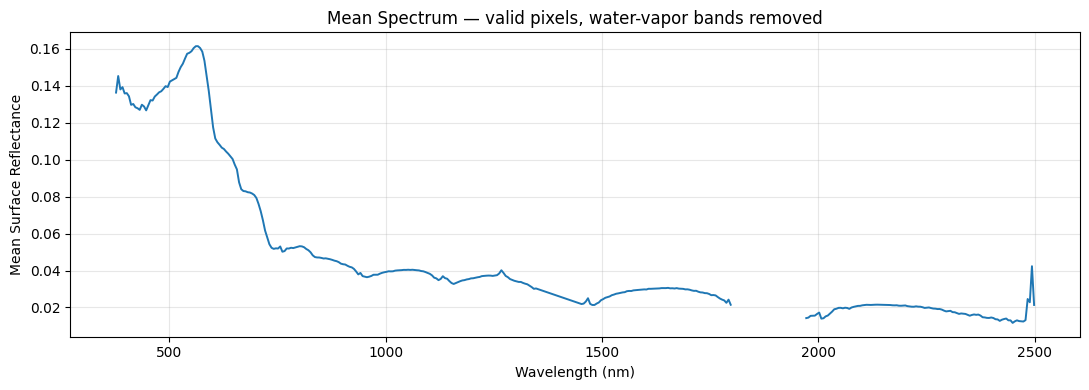

In [16]:
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

stride = 8
with h5py.File(local_path, "r") as f:
    sr = f[f"{root}/surface_reflectance"]
    good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_water_vapor(w)]
    cube = sr[good_idx, ::stride, ::stride].astype("float32")
    mask = valid[::stride, ::stride]
    cube[:, ~mask] = np.nan
    cube[cube < 0] = np.nan
    mean_spec = np.nanmean(cube, axis=(1,2))

import matplotlib.pyplot as plt
wls = [wavelengths_nm[i] for i in good_idx]
plt.figure(figsize=(11,4))
plt.plot(wls, mean_spec, lw=1.4)
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Mean Spectrum — valid pixels, water-vapor bands removed")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Step 13 – Water vs Vegetation Spectral Comparison

Compare the average spectrum of water pixels (NDWI > 0.1) vs vegetation pixels (NDVI > 0.3).


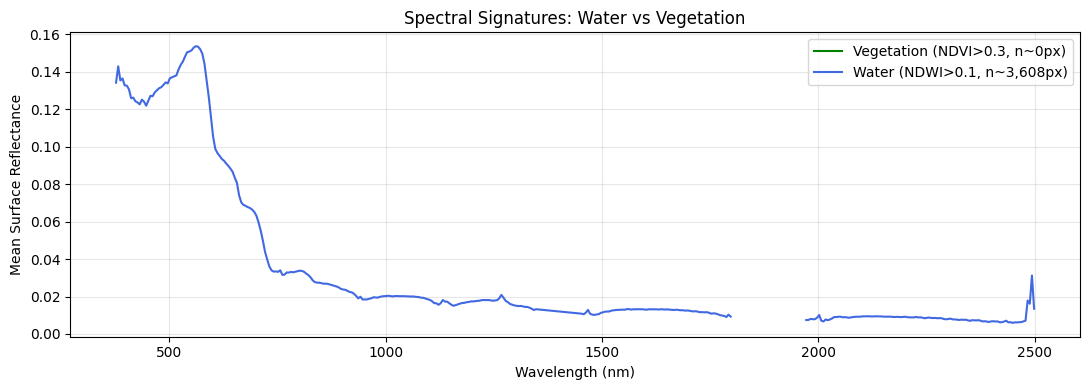

In [17]:
import h5py, matplotlib.pyplot as plt

stride = 8
def is_water_vapor(wl):
    return (1350 <= wl <= 1450) or (1800 <= wl <= 1950)

good_idx = [i for i, w in enumerate(wavelengths_nm) if not is_water_vapor(w)]
wls = [wavelengths_nm[i] for i in good_idx]

water_mask = (NDWI > 0.1) & valid
veg_mask   = (NDVI > 0.3) & valid

def mean_spec(mask):
    with h5py.File(local_path, "r") as f:
        sr = f[f"{root}/surface_reflectance"]
        cube = sr[good_idx, ::stride, ::stride].astype("float32")
    m = mask[::stride, ::stride]
    cube[:, ~m] = np.nan
    cube[cube < 0] = np.nan
    return [float(np.nanmean(cube[j])) for j in range(len(good_idx))]

spec_water = mean_spec(water_mask)
spec_veg   = mean_spec(veg_mask)

plt.figure(figsize=(11, 4))
plt.plot(wls, spec_veg,   color="green",  lw=1.5, label=f"Vegetation (NDVI>0.3, n~{veg_mask.sum()//stride**2:,}px)")
plt.plot(wls, spec_water, color="royalblue", lw=1.5, label=f"Water (NDWI>0.1, n~{water_mask.sum()//stride**2:,}px)")
plt.xlabel("Wavelength (nm)"); plt.ylabel("Mean Surface Reflectance")
plt.title("Spectral Signatures: Water vs Vegetation")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 🚀 Hackathon Challenge Ideas

- **Mangrove area estimation** — threshold the Mangrove_proxy map and compute area in km²
- **Algal bloom detection** — find pixels where NDCI > 0.2 within NDWI-positive water bodies
- **Seagrass mapping** — shallow water with positive NDVI signature
- **Carbon stock estimation** — combine mangrove extent with published carbon density values (t C/ha)
- **Turbidity monitoring** — track sediment plumes from rivers or coastal construction

> 📖 Created by: [LInkedin: Dr. Vincent Markiet - Space42](https://www.linkedin.com/in/vincentmarkiet/) 

> 📖 Data license: CC-BY-4.0 © Planet Labs PBC
